<h1 style="
    background-color: #d0ebff;
    color: #1a1a1a;
    display: inline-block;
    padding: 10px 18px;
    border-radius: 10px;
    font-size: 32px;
">
Feature Engineering Experiments
</h1>


Este notebook reúne pruebas de feature engineering orientadas a mejorar la predicción de precios. En particular, se evalúa si la columna `Versión` aporta información útil sobre el nivel de equipamiento del vehículo.

La idea es mantener el experimento simple y reproducible: partir de los datasets ya separados, crear nuevas variables, volver a aplicar one-hot encoding y comparar el desempeño del modelo.


In [20]:
import importlib
import sys

import pandas as pd

sys.path.append("../src")

import data_splitting as split
import eda_utils as eda
import feature_engeneering as fe
import modeling as mod
import preprocessing as prep
import visualization as visual

importlib.reload(eda)
importlib.reload(fe)
importlib.reload(mod)
importlib.reload(prep)
importlib.reload(visual)


<module 'visualization' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/visualization.py'>

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Data Loading
</h3>


In [22]:
dataset_processed = pd.read_csv("../data/dataset_pp.csv")

X_train = pd.read_csv("../data/X_train.csv")
X_val = pd.read_csv("../data/X_val.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")


X_train shape: (14579, 24)
X_val shape: (3644, 24)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Version Analysis
</h3>


La variable `Versión` contiene información sobre equipamiento, tracción y estilo de la publicación. En lugar de usarla directamente como texto libre, se busca extraer señales más simples: un nivel ordinal de versión y algunos indicadores binarios.

Antes de crear las variables, revisamos cómo varían las versiones dentro de cada combinación de `Marca` y `Modelo`.


In [23]:
version_summary = (
    dataset_processed
    .groupby(["Marca", "Modelo", "Versión"])["Precio"]
    .agg(
        count="count",
        median_price="median",
        mean_price="mean",
    )
    .reset_index()
    .sort_values(["Marca", "Modelo", "count"], ascending=[True, True, False])
)

version_summary.head(50)


,Marca,Modelo,Versión,count,median_price,mean_price
3,alfa romeo,stelvio,2.0 280cv At Q4 Veloce,12,86000.000000,81816.666667
1,alfa romeo,stelvio,2.0 200cv Distinctive Q4,5,45000.000000,48660.000000
2,alfa romeo,stelvio,2.0 280cv At Q4 Super,4,65500.000000,66875.000000
0,alfa romeo,stelvio,2.0 200cv,1,41500.000000,41500.000000
4,alfa romeo,stelvio,280cv SUPER,1,55000.000000,55000.000000
5,alfa romeo,stelvio,New Stelvio Tributo Italiano,1,86000.000000,86000.000000
6,alfa romeo,stelvio,Stelvio Ferrari Quadrifoglio 510cv,1,230000.000000,230000.000000
12,audi,q2,1.5 35 Tfsi Advanced 150 Cv,17,51500.000000,51829.411765
11,audi,q2,1.4 Tfsi Sport 150 Cv,14,30995.000000,32027.857143
10,audi,q2,1.4 Tfsi Serie 150 Cv,8,34999.078907,39261.403516


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Version Feature Definitions
</h3>


Se definen patrones de texto para identificar versiones base, medias, altas y premium. Como la clasificación no es perfecta, también se crea una variable `Version_Tier_Unknown` para marcar los casos donde no se detectó ninguna palabra clave.

Además del tier ordinal, se agregan indicadores binarios para señales que pueden afectar el precio pero no representan exactamente un nivel de equipamiento, como tracción `4x4`, versiones deportivas o extras.


In [24]:
PREMIUM_VERSION_PATTERNS = [
    r"\bpremium\b",
    r"\bplatinum\b",
    r"\bsummit\b",
    r"\boverland\b",
    r"\bhigh country\b",
    r"\bhigh altitude\b",
    r"\bluxury\b",
    r"\btouring\b",
    r"\bamg\b",
    r"\bm sport\b",
    r"\bm performance\b",
    r"\bs-?line\b",
    r"\br-?line\b",
    r"\braptor\b",
    r"\bsahara\b",
    r"\brubicon\b",
]

HIGH_VERSION_PATTERNS = [
    r"\blimited\b",
    r"\bhighline\b",
    r"\btitanium\b",
    r"\bpremier\b",
    r"\bexclusive\b",
    r"\bfeline\b",
    r"\bshine\b",
    r"\btrailhawk\b",
    r"\bsrx\b",
    r"\bseg\b",
    r"\bxle\b",
    r"\bex-?l\b",
    r"\biconic\b",
    r"\bintens\b",
    r"\bimpetus\b",
    r"\baudace\b",
    r"\bxline\b",
    r"\bsx\b",
    r"\bltz\+?\b",
    r"\bserie[- ]?s\b",
]

MID_VERSION_PATTERNS = [
    r"\bcomfortline\b",
    r"\ballure\b",
    r"\badvance\b",
    r"\bxei\b",
    r"\bxls\b",
    r"\bsrv\b",
    r"\bex\b",
    r"\bgls\b",
    r"\bsel\b",
    r"\blt\b",
    r"\blongitude\b",
    r"\bprivilege\b",
    r"\bdynamique\b",
    r"\bzen\b",
    r"\bfeel\b",
    r"\bstyle\b",
    r"\bfreestyle\b",
    r"\blife\b",
    r"\bse\b",
    r"\bdrive\b",
]

BASE_VERSION_PATTERNS = [
    r"\bbase\b",
    r"\bentry\b",
    r"\btrendline\b",
    r"\bsense\b",
    r"\bactive\b",
    r"\bxli\b",
    r"\bls\b",
    r"\blx\b",
    r"\bxl\b",
    r"\b1lt\b",
    r"\bexpression\b",
    r"\bgl\b",
]

VERSION_4X4_PATTERNS = [
    r"\b4x4\b",
    r"\b4wd\b",
    r"\bawd\b",
    r"\b4motion\b",
    r"\bxdrive\b",
    r"\bquattro\b",
    r"\b4matic\b",
]

VERSION_SPORT_PATTERNS = [
    r"\bsport\b",
    r"\bsportline\b",
    r"\bgt\b",
    r"\bgt[- ]?line\b",
    r"\brs\b",
    r"\babarth\b",
    r"\bgr[- ]?s\b",
    r"\btrailhawk\b",
]

VERSION_EXTRA_PATTERNS = [
    r"\bplus\b",
    r"\bpack\b",
    r"\bpk\b",
    r"\bfull\b",
    r"\btop\b",
    r"\btecho\b",
    r"\bcuero\b",
    r"\bnav\b",
    r"\bbitono\b",
    r"\bbi tono\b",
]

VERSION_TIER_PATTERNS = {
    3: PREMIUM_VERSION_PATTERNS,
    2: HIGH_VERSION_PATTERNS,
    1: MID_VERSION_PATTERNS,
    0: BASE_VERSION_PATTERNS,
}

VERSION_BINARY_PATTERNS = {
    "4x4": VERSION_4X4_PATTERNS,
    "Sport": VERSION_SPORT_PATTERNS,
    "Extra": VERSION_EXTRA_PATTERNS,
}


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Creation
</h3>


In [25]:
X_train_fe = fe.add_text_pattern_features(
    X_train,
    source_col="Versión",
    tier_patterns=VERSION_TIER_PATTERNS,
    binary_patterns=VERSION_BINARY_PATTERNS,
    prefix="Version",
    default_tier=1,
    drop_source_col=True,
)

X_val_fe = fe.add_text_pattern_features(
    X_val,
    source_col="Versión",
    tier_patterns=VERSION_TIER_PATTERNS,
    binary_patterns=VERSION_BINARY_PATTERNS,
    prefix="Version",
    default_tier=1,
    drop_source_col=True,
)

X_train_fe = prep.drop_irrelevant_columns(
    X_train_fe,
    columns_to_drop=["Título", "Descripción"],
)

X_val_fe = prep.drop_irrelevant_columns(
    X_val_fe,
    columns_to_drop=["Título", "Descripción"],
)

X_train_fe.head()


,Marca,Modelo,Año,Color,Tipo de combustible,Puertas,Transmisión,Con cámara de retroceso,Kilómetros,Tipo de vendedor,...,cuidado,detalles_uso,daño,sin_choque,sin_condicion,Version_Tier,Version_Tier_Unknown,Version_4x4,Version_Sport,Version_Extra
0,volkswagen,t cross,2020.0,gris,nafta,5.0,automatica,NaN,68000,concesionaria,...,0,0,0,0,1,2,0,0,0,0
1,honda,pilot,2009.0,gris,nafta,4.0,automatica,NaN,235000,concesionaria,...,0,0,0,0,1,3,0,0,0,0
2,volkswagen,t cross,2025.0,blanco,nafta,5.0,automatica,NaN,0,tienda,...,0,0,0,0,1,1,0,0,0,0
3,chevrolet,tracker,2018.0,gris,nafta,5.0,manual,NaN,109141,tienda,...,0,0,0,0,1,2,0,0,0,0
4,peugeot,2008,2019.0,blanco,nafta,5.0,manual,NaN,66391,concesionaria,...,0,0,0,0,0,2,0,0,0,0


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Encoding
</h3>


In [26]:
categorical_cols_to_encode = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión",
]

X_train_encoded, categories_map = prep.one_hot_encoding(
    X_train_fe,
    categorical_cols=categorical_cols_to_encode,
    train=True,
    binary_missing_cols=["Con cámara de retroceso"],
)

X_val_encoded = prep.one_hot_encoding(
    X_val_fe,
    categorical_cols=categorical_cols_to_encode,
    train=False,
    categories_map=categories_map,
    binary_missing_cols=["Con cámara de retroceso"],
)

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_val_encoded shape: {X_val_encoded.shape}")


X_train_encoded shape: (14579, 220)
X_val_encoded shape: (3644, 220)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Model Training
</h3>


In [27]:
xgboost_log_model, xgboost_log_metrics, xgboost_log_predictions = mod.train_xgboost(
    X_train_encoded,
    y_train,
    X_val_encoded,
    y_val,
    use_log_target=True,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgboost_log_metrics


,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,1.262069e+07,4.301226e+07,3552.561182,6558.372968,1985.896998,2528.812778,0.967048,0.896673


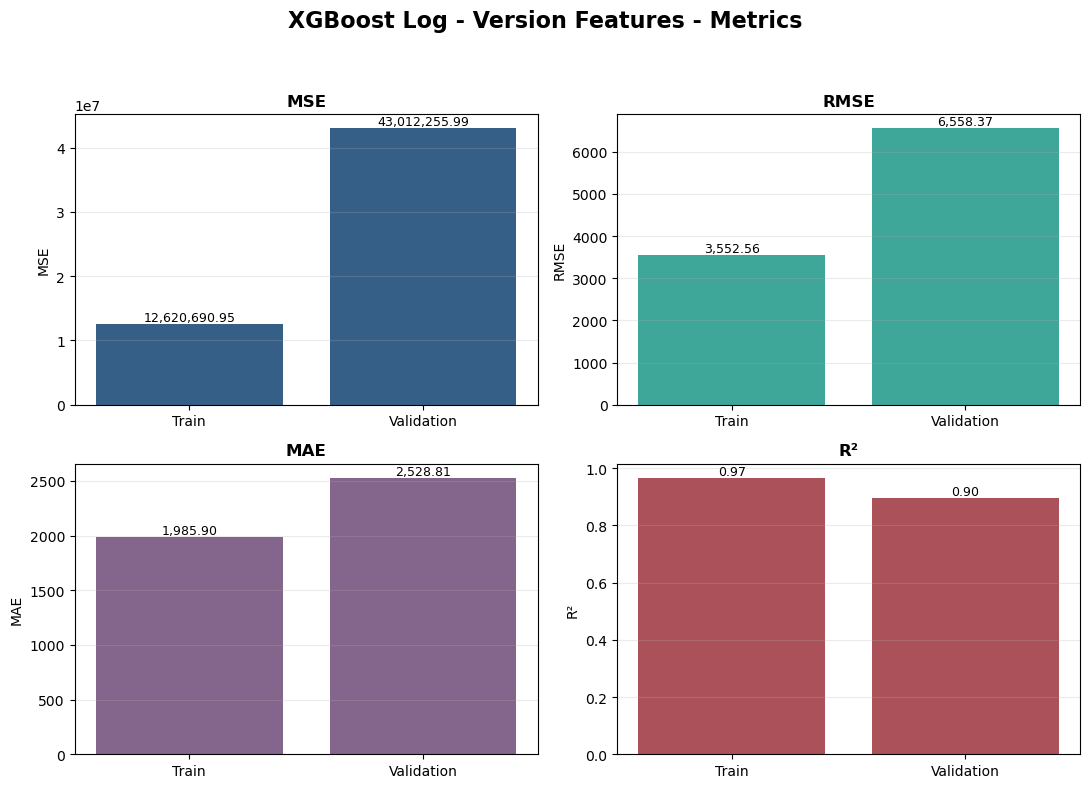

In [28]:
visual.plot_regression_metrics(
    xgboost_log_metrics,
    model_name="XGBoost Log - Version Features",
)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Diagnostics
</h3>


Luego de entrenar, revisamos si las variables creadas tienen cobertura suficiente y si el modelo efectivamente las utiliza. Esto ayuda a decidir si vale la pena conservarlas en el pipeline final.


In [29]:
version_feature_cols = [
    "Version_Tier",
    "Version_Tier_Unknown",
    "Version_4x4",
    "Version_Sport",
    "Version_Extra",
]

X_val_fe[version_feature_cols].mean().sort_values(ascending=False)


Version_Tier            1.325741
Version_Tier_Unknown    0.302964
Version_4x4             0.180296
Version_Extra           0.088913
Version_Sport           0.086169
dtype: float64

In [30]:
diagnostic_data = X_train_fe.copy()
diagnostic_data["Precio"] = y_train

(
    diagnostic_data
    .groupby("Version_Tier")["Precio"]
    .agg(
        count="count",
        median="median",
        mean="mean",
    )
    .sort_index()
)


,count,median,mean
Version_Tier,,,
0,943,20709.855695,21210.023943
1,8603,22500.000000,27572.068604
2,4516,26392.385631,28284.443357
3,517,29229.352165,40042.653852


In [31]:
(
    diagnostic_data
    .groupby(["Marca", "Modelo", "Version_Tier"])["Precio"]
    .agg(
        count="count",
        median="median",
    )
    .reset_index()
    .sort_values(["Marca", "Modelo", "Version_Tier"])
)


,Marca,Modelo,Version_Tier,count,median
0,alfa romeo,stelvio,1,20,83000.000000
1,audi,q2,1,56,49150.000000
2,audi,q3,1,88,40202.640467
3,audi,q3 sportback,1,33,62000.000000
4,audi,q5,1,159,31000.000000
...,...,...,...,...,...
227,volkswagen,touareg,1,7,25000.000000
228,volkswagen,touareg,3,7,22500.000000
229,volvo,xc40,1,4,60450.000000
230,volvo,xc60,1,24,44227.249002


In [32]:
feature_importance = pd.Series(
    xgboost_log_model.named_steps["regressor"].feature_importances_,
    index=X_train_encoded.columns,
).sort_values(ascending=False)

feature_importance.head(30)


Transmisión_manual      0.185265
Modelo_corolla cross    0.042534
Marca_bmw               0.033986
Cilindrada              0.031715
Marca_audi              0.028050
Modelo_wrangler         0.025285
Modelo_c4 cactus        0.024188
Año                     0.020939
Marca_mercedes benz     0.020663
Modelo_clase glc        0.020411
Version_4x4             0.020387
Modelo_tracker          0.018654
Marca_porsche           0.017332
Marca_fiat              0.017130
Marca_toyota            0.016471
Marca_renault           0.016407
Modelo_journey          0.014698
Modelo_ecosport         0.014548
Modelo_x6               0.014220
Modelo_x1               0.013345
Modelo_clase gla        0.012999
Marca_ford              0.011115
Modelo_macan            0.010845
Marca_volkswagen        0.009966
Marca_chery             0.008917
Marca_citroen           0.008598
Kilómetros              0.008461
Marca_jeep              0.008322
Marca_dodge             0.007949
Marca_land rover        0.007922
dtype: flo

In [33]:
feature_importance[feature_importance.index.str.contains("Version")]


Version_4x4             0.020387
Version_Tier_Unknown    0.005625
Version_Sport           0.002157
Version_Tier            0.001985
Version_Extra           0.001643
dtype: float32

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Error Analysis
</h3>


Si la mejora es pequeña, conviene revisar dónde se equivoca el modelo. En particular, los errores grandes pueden venir de precios atípicos dentro de un mismo modelo, más que de la falta de información de `Versión`.


In [34]:
prediction_context = mod.attach_prediction_context(
    xgboost_log_predictions,
    X_train_fe,
    X_val_fe,
)

mod.top_prediction_errors(
    prediction_context,
    split="validation",
    n=20,
).style.hide(axis="index")


split,row_index,Marca,Modelo,Año,Kilómetros,Cilindrada,Transmisión,Tipo de combustible,Color,Tipo de vendedor,Con cámara de retroceso,y_true,y_pred,residual,abs_error,signed_pct_error,abs_pct_error
validation,3335,porsche,cayenne,2022.000000,14000,4.000000,automatica,nafta,gris,tienda,1.000000,345000.000000,158215.515625,186784.484375,186784.484375,54.140430,54.140430
validation,2938,volkswagen,nivus,2024.000000,0,1.000000,automatica,nafta,gris,concesionaria,nan,150000.000000,29725.669922,120274.330078,120274.330078,80.182887,80.182887
validation,2516,bmw,x5,2024.000000,11972,3.000000,automatica,nafta,gris,concesionaria,nan,249000.000000,137293.500000,111706.500000,111706.500000,44.862048,44.862048
validation,2723,alfa romeo,stelvio,2024.000000,0,3.000000,automatica,nafta,negro,concesionaria,nan,230000.000000,121463.859375,108536.140625,108536.140625,47.189626,47.189626
validation,1890,bmw,x3,2021.000000,13500,3.000000,automatica,nafta,gris,concesionaria,nan,198000.000000,109257.078125,88742.921875,88742.921875,44.819658,44.819658
validation,762,bmw,x3,2019.000000,5000,2.000000,automatica,nafta,azul,particular,nan,133000.000000,76245.648438,56754.351562,56754.351562,42.672445,42.672445
validation,651,chevrolet,equinox,2020.000000,87,1.500000,automatica,nafta,blanco,concesionaria,nan,85968.681977,32279.460938,53689.221040,53689.221040,62.452070,62.452070
validation,1960,jeep,grand cherokee,2019.000000,47000,6.400000,automatica,nafta,rojo,particular,nan,125000.000000,76171.304688,48828.695312,48828.695312,39.062956,39.062956
validation,801,bmw,x3,2021.000000,32000,3.000000,automatica,nafta,negro,particular,nan,70000.000000,117556.695312,-47556.695312,47556.695312,-67.938136,67.938136
validation,3619,bmw,x5,2024.000000,0,5.000000,automatica,nafta,negro,tienda,nan,180000.000000,138180.828125,41819.171875,41819.171875,23.232873,23.232873


In [35]:
mod.summarize_prediction_errors(
    prediction_context,
    group_cols=["Marca", "Modelo"],
    split="validation",
    min_count=5,
).head(20).style.hide(axis="index")


Marca,Modelo,count,mae,median_abs_error,rmse,mean_residual,median_y_true,median_y_pred,mean_abs_pct_error,bias_direction
porsche,cayenne,10,25365.432617,7160.043945,59607.028472,22557.421680,43500.000000,39586.445312,20.971521,underprediction
alfa romeo,stelvio,5,25363.293750,5084.921875,48723.515304,24308.590625,74000.000000,67927.125000,15.333539,underprediction
audi,q8,5,17735.393750,14429.437500,19968.456476,11963.618750,177000.000000,171753.687500,10.023078,underprediction
bmw,x3,22,15618.927246,6097.503906,27224.434049,5504.998890,57000.000000,61580.082031,20.635159,underprediction
bmw,x5,18,12592.802897,3780.415039,28928.894618,9435.785102,34850.000000,37529.980469,14.377978,underprediction
bmw,x2,6,11946.736328,5583.607422,17971.504426,9528.365234,73950.000000,63640.070312,13.683375,underprediction
mercedes benz,clase glc,22,11540.274680,7283.423828,15626.752140,5867.961825,57650.000000,56974.826172,15.346664,underprediction
mercedes benz,clase gle,10,11426.107813,7402.371094,14462.714465,9896.929688,77500.000000,70498.968750,13.366409,underprediction
chevrolet,equinox,10,7945.227735,3614.450868,17308.710152,5356.620646,26990.067547,28367.099609,15.474419,underprediction
toyota,land cruiser,11,7649.656616,3972.121094,10187.475740,6693.846246,40000.000000,29559.722656,16.833652,underprediction
